<a href="https://colab.research.google.com/github/sudharsan0503/DL/blob/main/cnn1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
from tensorflow.keras.backend import clear_session

clear_session()

X_train: (60000, 28, 28)
X_test : (10000, 28, 28)
y_train: (60000, 10)
y_test : (10000, 10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8779 - loss: 0.4689 - val_accuracy: 0.9155 - val_loss: 0.3050
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9149 - loss: 0.3040 - val_accuracy: 0.9235 - val_loss: 0.2814
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9215 - loss: 0.2839 - val_accuracy: 0.9222 - val_loss: 0.2779
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9235 - loss: 0.2730 - val_accuracy: 0.9231 - val_loss: 0.2710
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9259 - loss: 0.2666 - val_accuracy: 0.9259 - val_loss: 0.2674

Test Accuracy : 0.9258999824523926
Test Loss     : 0.267374187707901


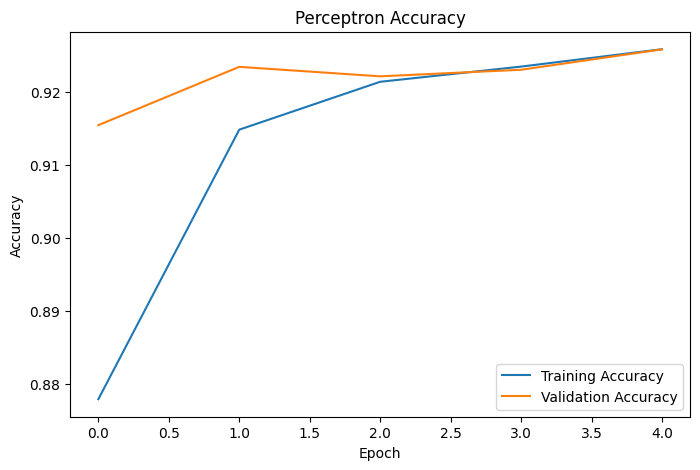

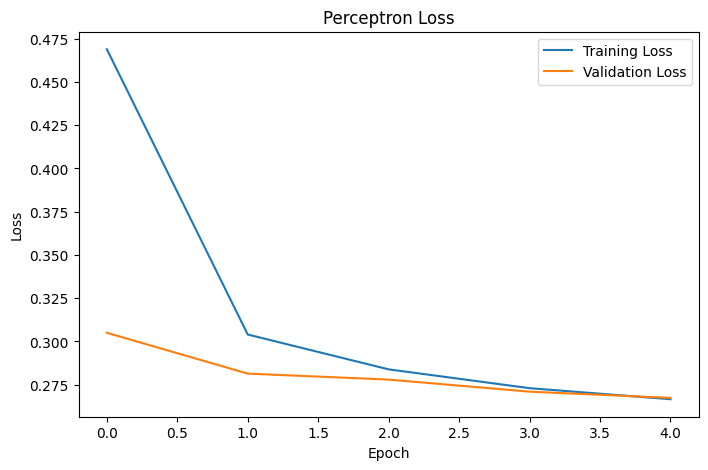

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.backend import clear_session

# ==========================
# Load Dataset
# ==========================
df_train = pd.read_csv('mnist_train.csv')
df_test = pd.read_csv('mnist_test.csv')

# ==========================
# Separate Features & Labels
# ==========================
X_train = df_train.drop('label', axis=1).values
y_train = df_train['label'].values

X_test = df_test.drop('label', axis=1).values
y_test = df_test['label'].values

# ==========================
# Normalize Pixel Values
# ==========================
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# ==========================
# Reshape for Neural Network
# ==========================
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

# ==========================
# One-Hot Encoding
# ==========================
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# ==========================
# Check Shapes
# ==========================
print("X_train:", X_train_img.shape)
print("X_test :", X_test_img.shape)
print("y_train:", y_train_cat.shape)
print("y_test :", y_test_cat.shape)

# ==========================
# Clear Old Models
# ==========================
clear_session()

# ==========================
# Perceptron Model
# ==========================
perceptron = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(10, activation='softmax')
])

# ==========================
# Compile Model
# ==========================
perceptron.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================
# Model Summary
# ==========================
perceptron.summary()

# ==========================
# Train Model
# ==========================
history = perceptron.fit(
    X_train_img,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_img, y_test_cat),
    verbose=1
)

# ==========================
# Evaluate Model
# ==========================
loss, accuracy = perceptron.evaluate(
    X_test_img,
    y_test_cat,
    verbose=0
)

print("\nTest Accuracy :", accuracy)
print("Test Loss     :", loss)

# ==========================
# Accuracy Graph
# ==========================
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Perceptron Accuracy')
plt.legend()
plt.show()

# ==========================
# Loss Graph
# ==========================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Perceptron Loss')
plt.legend()
plt.show()

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Flatten, Dense
from tensorflow.keras.backend import clear_session

clear_session()

ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

ann.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
history_ann = ann.fit(
    X_train_img,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_img, y_test_cat),
    verbose=1
    )

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9305 - loss: 0.2378 - val_accuracy: 0.9629 - val_loss: 0.1237
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9699 - loss: 0.0999 - val_accuracy: 0.9706 - val_loss: 0.0902
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9786 - loss: 0.0697 - val_accuracy: 0.9738 - val_loss: 0.0838
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9828 - loss: 0.0544 - val_accuracy: 0.9756 - val_loss: 0.0783
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9866 - loss: 0.0414 - val_accuracy: 0.9731 - val_loss: 0.0874


In [58]:
loss_ann, acc_ann = ann.evaluate(
    X_test_img,
    y_test_cat,
    verbose=0
)

print("ANN Accuracy:", acc_ann)
print("ANN Loss:", loss_ann)

ANN Accuracy: 0.9731000065803528
ANN Loss: 0.08740586787462234


In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)
from tensorflow.keras.backend import clear_session

# Clear previous models
clear_session()

# CNN needs channel dimension
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

cnn = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn.summary()

history_cnn = cnn.fit(
    X_train_cnn,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_cnn, y_test_cat),
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - accuracy: 0.9624 - loss: 0.1236 - val_accuracy: 0.9846 - val_loss: 0.0448
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9862 - loss: 0.0436 - val_accuracy: 0.9897 - val_loss: 0.0330
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9906 - loss: 0.0283 - val_accuracy: 0.9891 - val_loss: 0.0358
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9935 - loss: 0.0208 - val_accuracy: 0.9885 - val_loss: 0.0365
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9951 - loss: 0.0153 - val_accuracy: 0.9881 - val_loss: 0.0399


In [60]:
loss_cnn, acc_cnn = cnn.evaluate(
    X_test_cnn,
    y_test_cat,
    verbose=0
)

print("CNN Accuracy :", acc_cnn)
print("CNN Loss     :", loss_cnn)


CNN Accuracy : 0.988099992275238
CNN Loss     : 0.03985125571489334


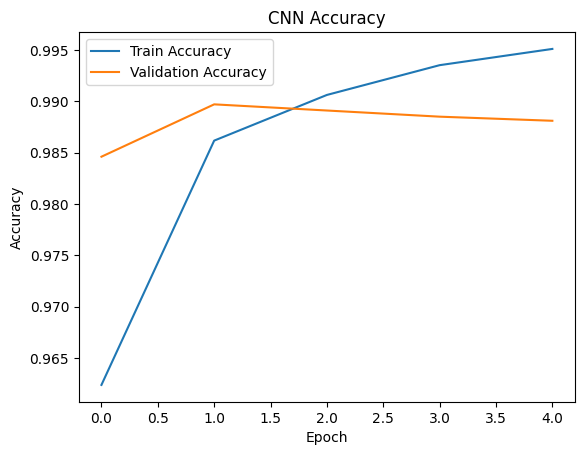

In [61]:
import matplotlib.pyplot as plt

plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.show()

In [65]:
acc_percp = perceptron.evaluate(
    X_test_img,
    y_test_cat,
    verbose=0
)
print("Perceptron Accuracy :", acc_percp[1])
print("ANN Accuracy        :", acc_ann)
print("CNN Accuracy        :", acc_cnn)

Perceptron Accuracy : 0.9258999824523926
ANN Accuracy        : 0.9731000065803528
CNN Accuracy        : 0.988099992275238


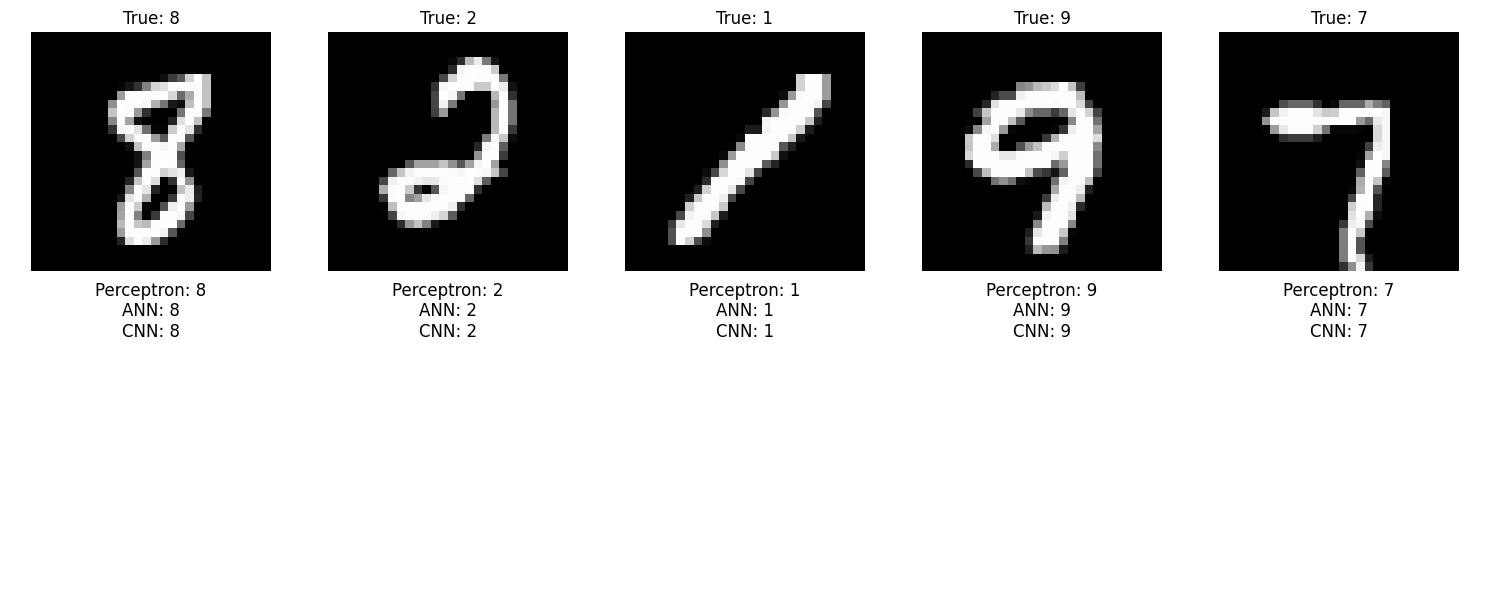

In [66]:
import numpy as np
import matplotlib.pyplot as plt

def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):

    idxs = np.random.choice(len(X), n, replace=False)

    plt.figure(figsize=(15, 6))

    for i, idx in enumerate(idxs):

        # Show Image
        plt.subplot(2, n, i + 1)
        plt.imshow(X[idx].reshape(28, 28), cmap='gray')
        plt.axis('off')
        plt.title(f"True: {y_true[idx]}")

        # Predictions from all models
        preds = []

        for model, name in zip(models, model_names):

            if name == "CNN":
                pred = np.argmax(
                    model.predict(
                        X_cnn[idx].reshape(1, 28, 28, 1),
                        verbose=0
                    )
                )
            else:
                pred = np.argmax(
                    model.predict(
                        X[idx].reshape(1, 28, 28),
                        verbose=0
                    )
                )

            preds.append(pred)

        # Show Predictions
        plt.subplot(2, n, n + i + 1)
        plt.axis('off')

        text = "\n".join(
            [f"{name}: {pred}" for name, pred in zip(model_names, preds)]
        )

        plt.title(text)

    plt.tight_layout()
    plt.show()


# CNN format data
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

# Compare models
show_side_by_side(
    [perceptron, ann, cnn],
    ["Perceptron", "ANN", "CNN"],
    X_test_img,
    X_test_cnn,
    y_test,
    n=5
)